In [1]:
%cd ..

C:\Users\malte\EvoMUSART23-repro-code


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import os
from scipy.stats import t

smsemoa_path = "experiments/moea/tiny_aam/smsemoa/recall"
nsga_path = "experiments/moea/tiny_aam/nsga2/recall"
ea_path = "experiments/moea/tiny_aam/ea"
# -------------------------------------------------
# Load Data
# -------------------------------------------------

smsemoa_df = pd.read_csv(os.path.join(smsemoa_path, "jaccard_GD_IGD_SMSEMOA_300.csv"))
nsga_df = pd.read_csv(os.path.join(nsga_path, "jaccard_GD_IGD_NSGA2_300.csv"))
soea_population_df = pd.read_csv(os.path.join(ea_path,"jaccard_GD_IGD_EA_300.csv"))
soea_archive_df = pd.read_csv(os.path.join(ea_path,"jaccard_GD_IGD_EA_Archive_300.csv"))

# Ensure string type
nsga_df["piece"] = nsga_df["piece"].astype(str)
smsemoa_df["piece"] = smsemoa_df["piece"].astype(str)
soea_archive_df["piece"] = soea_archive_df["piece"].astype(str)
soea_population_df["piece"] = soea_population_df["piece"].astype(str)

# Count number of objectives
smsemoa_df["n_objectives"] = smsemoa_df["objectives"].apply(lambda x: len(x.split("__")))
nsga_df["n_objectives"] = nsga_df["objectives"].apply(lambda x: len(x.split("__")))
soea_archive_df["n_objectives"] = soea_archive_df["objectives"].apply(lambda x: len(x.split("__")))
soea_population_df["n_objectives"] = soea_population_df["objectives"].apply(lambda x: len(x.split("__")))

In [3]:
def summarize_metric(df, metric):
    summary = (
        df.groupby("piece")[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    
    t_value = t.ppf(0.975, df=summary["count"] - 1)
    summary["ci"] = t_value * summary["std"] / np.sqrt(summary["count"])
    
    return summary

# -------------------------------------------------
# Compute mean + 95% CI for MOEA
# -------------------------------------------------
smsemoa_GD = summarize_metric(smsemoa_df, "GD")
nsga_GD = summarize_metric(nsga_df, "GD")
soea_archive_GD = summarize_metric(soea_archive_df, "GD")
soea_population_GD = summarize_metric(soea_population_df, "GD")

smsemoa_IGD = summarize_metric(smsemoa_df, "IGD")
nsga_IGD = summarize_metric(nsga_df, "IGD")
soea_archive_IGD = summarize_metric(soea_archive_df, "IGD")
soea_population_IGD = summarize_metric(soea_population_df, "IGD")

In [4]:
piece_order = sorted(smsemoa_df["piece"].unique())
def align(summary):
    return summary.set_index("piece").loc[piece_order].reset_index()


smsemoa_GD = align(smsemoa_GD)
nsga_GD = align(nsga_GD)
soea_archive_GD = align(soea_archive_GD)
soea_population_GD = align(soea_population_GD)

smsemoa_IGD = align(smsemoa_IGD)
nsga_IGD = align(nsga_IGD)
soea_archive_IGD = align(soea_archive_IGD)
soea_population_IGD = align(soea_population_IGD)

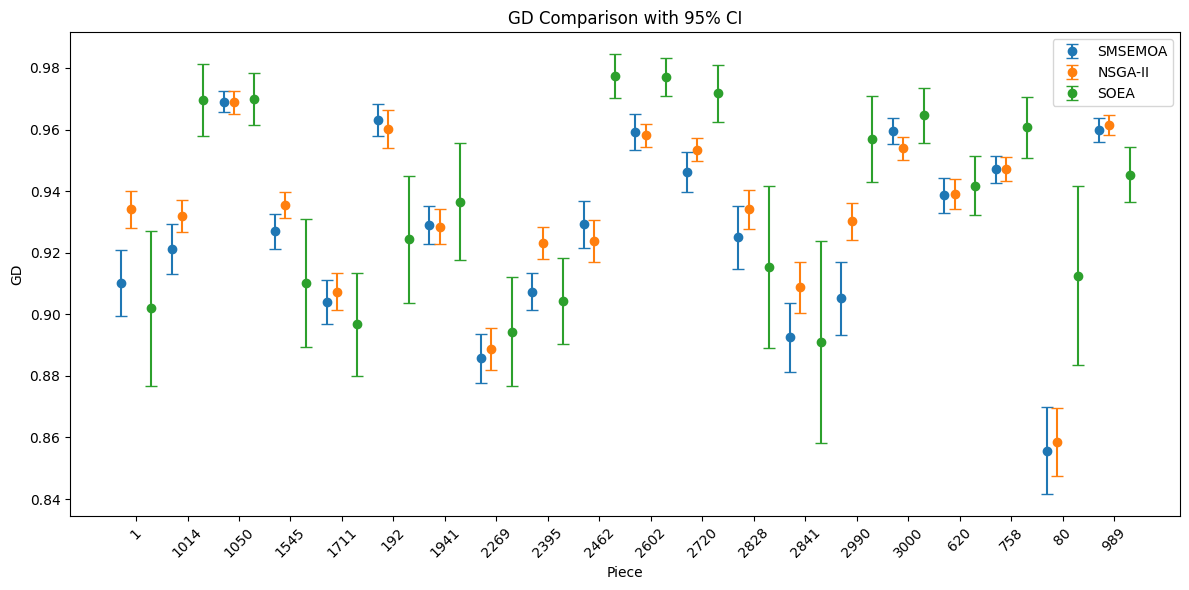

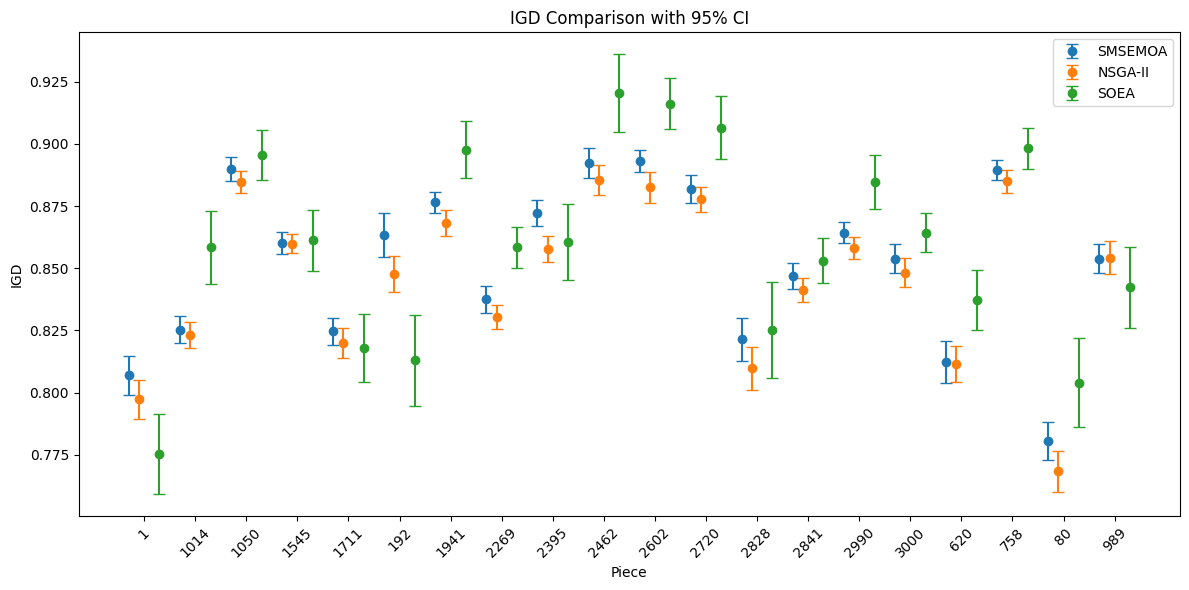

In [5]:
def plot_metric(metric_name, smsemoa, nsga, soea_arch, soea_pop):
    x = np.arange(len(smsemoa["piece"]))
    width = 0.2

    plt.figure(figsize=(12, 6))

    plt.errorbar(x - 1.5*width, smsemoa["mean"], yerr=smsemoa["ci"],
             fmt='o', label="SMSEMOA", capsize=4)

    plt.errorbar(x - 0.5*width, nsga["mean"], yerr=nsga["ci"],
                 fmt='o', label="NSGA-II", capsize=4)

    #plt.errorbar(x + 0.5*width, soea_arch["mean"], yerr=soea_arch["ci"],
    #             fmt='o', label="SOEA Archive", capsize=4)

    plt.errorbar(x + 1.5*width, soea_pop["mean"], yerr=soea_pop["ci"],
                 fmt='o', label="SOEA", capsize=4)

    plt.xticks(x, smsemoa["piece"], rotation=45)
    plt.xlabel("Piece")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} Comparison with 95% CI")

    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric("GD", smsemoa_GD, nsga_GD, soea_archive_GD, soea_population_GD)
plot_metric("IGD", smsemoa_IGD, nsga_IGD, soea_archive_IGD, soea_population_IGD)    

In [6]:
def summarize_by_objectives(df, metric):
    summary = (
        df.groupby("n_objectives")[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    
    t_value = t.ppf(0.975, df=summary["count"] - 1)
    summary["ci"] = t_value * summary["std"] / np.sqrt(summary["count"])
    
    return summary

In [7]:
# GD
smsemoa_GD_obj = summarize_by_objectives(smsemoa_df, "GD")
nsga_GD_obj = summarize_by_objectives(nsga_df, "GD")
soea_GD_obj = summarize_by_objectives(soea_population_df, "GD")

# IGD
smsemoa_IGD_obj = summarize_by_objectives(smsemoa_df, "IGD")
nsga_IGD_obj = summarize_by_objectives(nsga_df, "IGD")
soea_IGD_obj = summarize_by_objectives(soea_population_df, "IGD")

all_objectives = sorted(
    set(smsemoa_GD_obj["n_objectives"]) |
    set(nsga_GD_obj["n_objectives"]) |
    set(soea_GD_obj["n_objectives"])
)

def align_objectives(summary):
    return (
        summary.set_index("n_objectives")
        .reindex(all_objectives)
        .reset_index()
    )

smsemoa_GD_obj = align_objectives(smsemoa_GD_obj)
nsga_GD_obj = align_objectives(nsga_GD_obj)
soea_GD_obj = align_objectives(soea_GD_obj)

smsemoa_IGD_obj = align_objectives(smsemoa_IGD_obj)
nsga_IGD_obj = align_objectives(nsga_IGD_obj)
soea_IGD_obj = align_objectives(soea_IGD_obj)

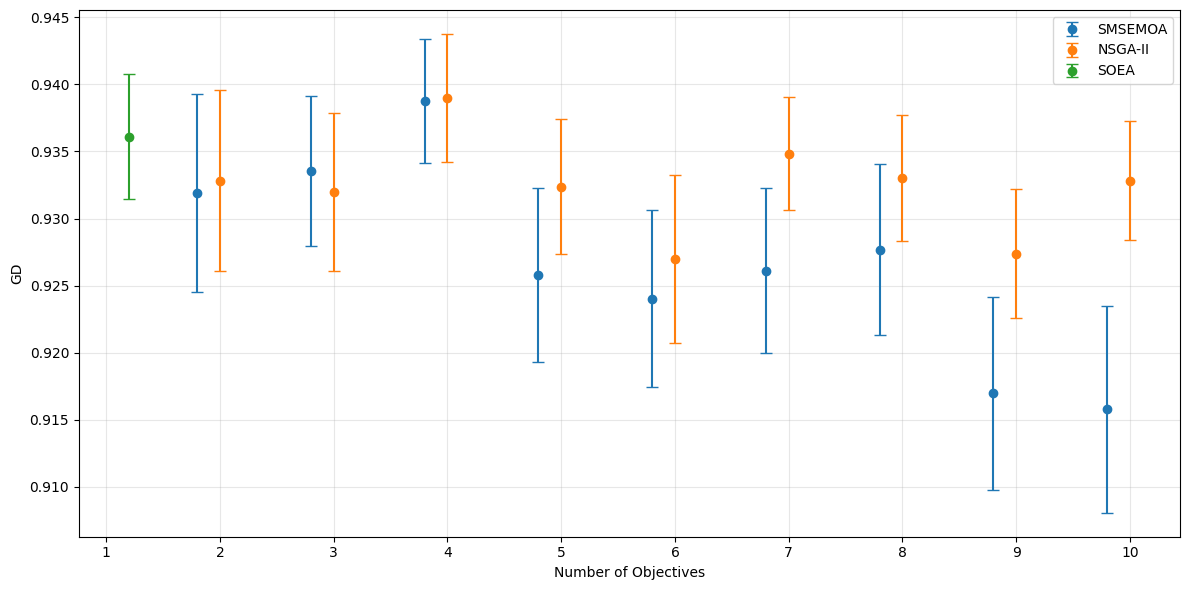

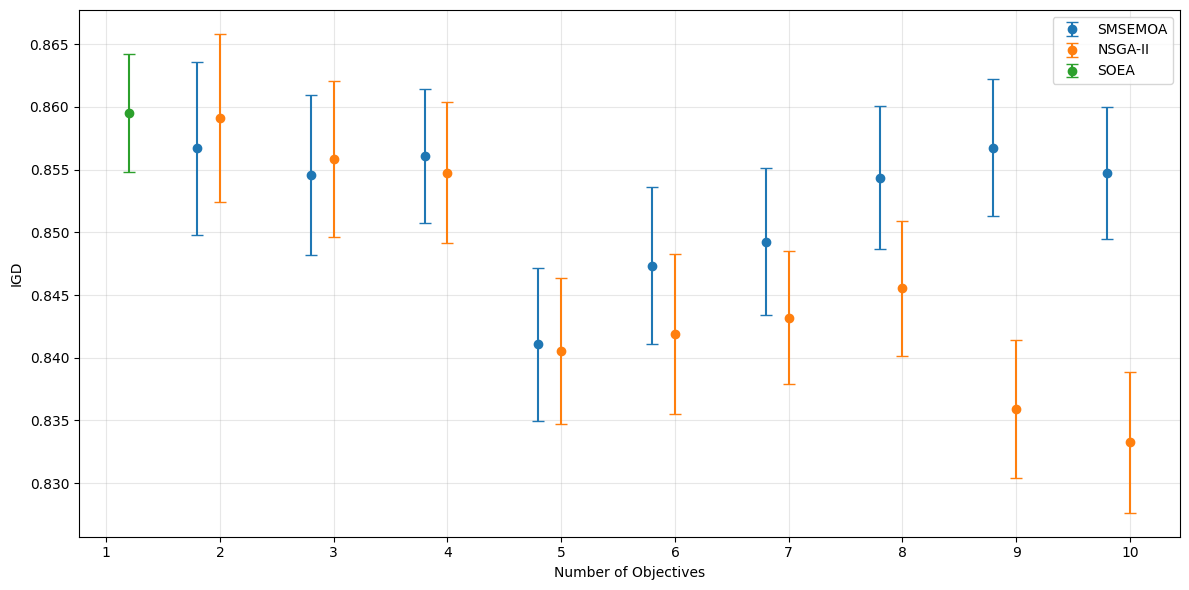

In [22]:
def plot_by_objectives(metric_name, smsemoa, nsga, soea):
    x = np.array(all_objectives)
    width = 0.2

    plt.figure(figsize=(12, 6))

    def plot_algo(offset, data, label):
        mask = ~data["mean"].isna()
        plt.errorbar(
            x[mask] + offset,
            data.loc[mask, "mean"],
            yerr=data.loc[mask, "ci"],
            fmt='o',
            label=label,
            capsize=4,  
            capthick=1      
        )

    plot_algo(-width, smsemoa, "SMS-EMOA")
    plot_algo(0, nsga, "NSGA-II")
    plot_algo(+width, soea, "SOEA")

    plt.xticks(x)
    plt.xlabel("Number of Objectives")
    plt.ylabel(metric_name)
    #plt.title(f"{metric_name} vs Number of Objectives (95% CI)")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    outpath = os.path.join("experiments", "moea", "plots", f"{metric_name}.pdf")
    plt.savefig(outpath, format="pdf", bbox_inches="tight")
    plt.show()
    
plot_by_objectives("GD", smsemoa_GD_obj, nsga_GD_obj, soea_GD_obj)
plot_by_objectives("IGD", smsemoa_IGD_obj, nsga_IGD_obj, soea_IGD_obj)

meta NOT subset; don't know how to subset; dropped


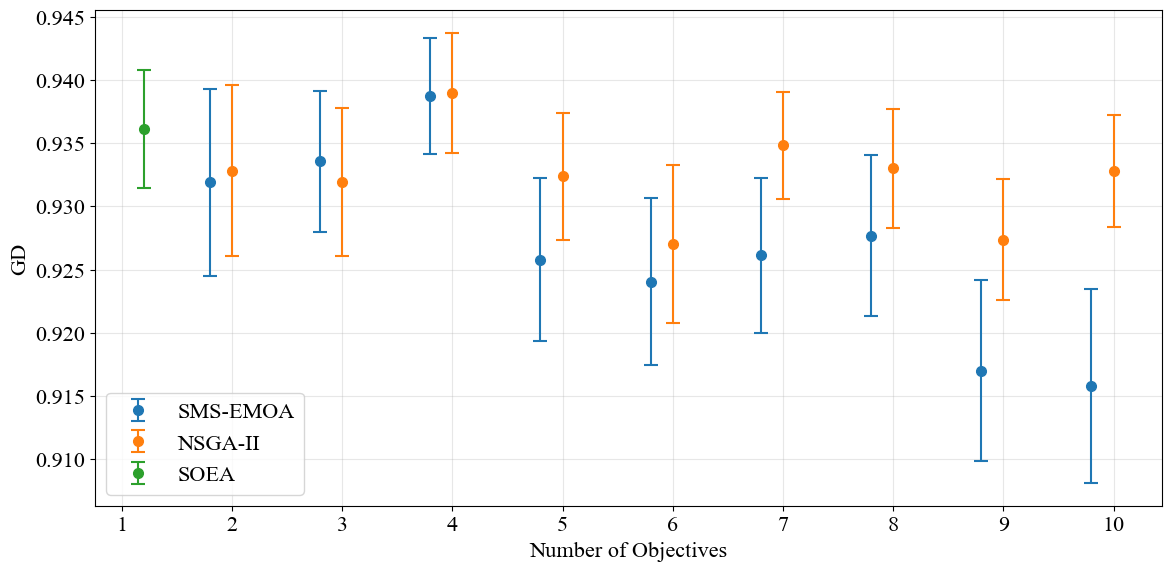

meta NOT subset; don't know how to subset; dropped


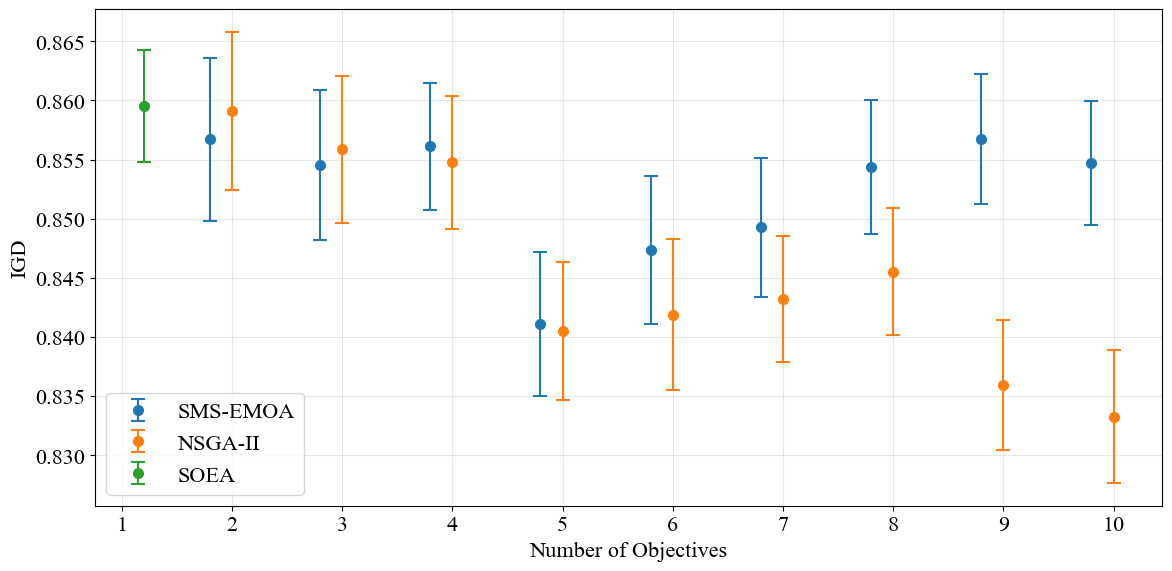

Times New Roman


In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Register Times New Roman explicitly
font_path = r"C:\Windows\Fonts\times.ttf"
fm.fontManager.addfont(font_path)

# Get the font's actual internal name
times_new_roman = fm.FontProperties(fname=font_path).get_name()

# Paper-style settings
plt.rcParams.update({
    "font.family": times_new_roman,

    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,

    # Embed TrueType fonts in the PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def plot_by_objectives(metric_name, smsemoa, nsga, soea):
    x = np.array(all_objectives)
    width = 0.2

    plt.figure(figsize=(12, 6))

    def plot_algo(offset, data, label):
        mask = ~data["mean"].isna()

        plt.errorbar(
            x[mask] + offset,
            data.loc[mask, "mean"],
            yerr=data.loc[mask, "ci"],
            fmt="o",
            label=label,
            capsize=5,
            capthick=1.5,
            markersize=7,
            linewidth=1.5
        )

    plot_algo(-width, smsemoa, "SMS-EMOA")
    plot_algo(0, nsga, "NSGA-II")
    plot_algo(+width, soea, "SOEA")

    plt.xticks(x)
    plt.xlabel("Number of Objectives")
    plt.ylabel(metric_name)

    plt.legend()

    plt.grid(alpha=0.3)
    plt.tight_layout()

    outpath = os.path.join(
        "experiments",
        "moea",
        "plots",
        f"{metric_name}.pdf"
    )

    plt.savefig(
        outpath,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()


plot_by_objectives(
    "GD",
    smsemoa_GD_obj,
    nsga_GD_obj,
    soea_GD_obj
)

plot_by_objectives(
    "IGD",
    smsemoa_IGD_obj,
    nsga_IGD_obj,
    soea_IGD_obj
)
print(times_new_roman)

In [9]:
def prepare_combined(df, metric, algo_name):
    summary = (
        df.groupby(["piece", "n_objectives"])[metric]
        .mean()
        .reset_index()
    )
    summary["algorithm"] = algo_name
    return summary

combined_GD = pd.concat([
    prepare_combined(smsemoa_df, "GD", "SMSEMOA"),
    prepare_combined(nsga_df, "GD", "NSGA-II"),
    prepare_combined(soea_population_df, "GD", "SOEA")
])

combined_IGD = pd.concat([
    prepare_combined(smsemoa_df, "IGD", "SMSEMOA"),
    prepare_combined(nsga_df, "IGD", "NSGA-II"),
    prepare_combined(soea_population_df, "IGD", "SOEA")
])

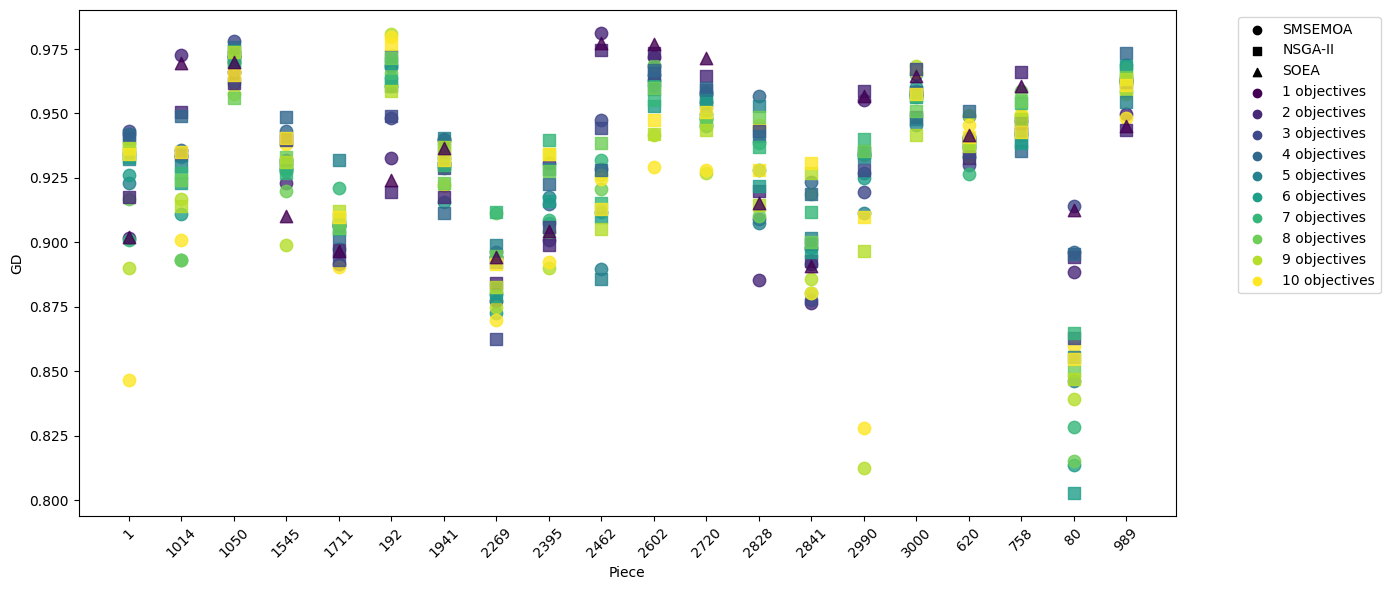

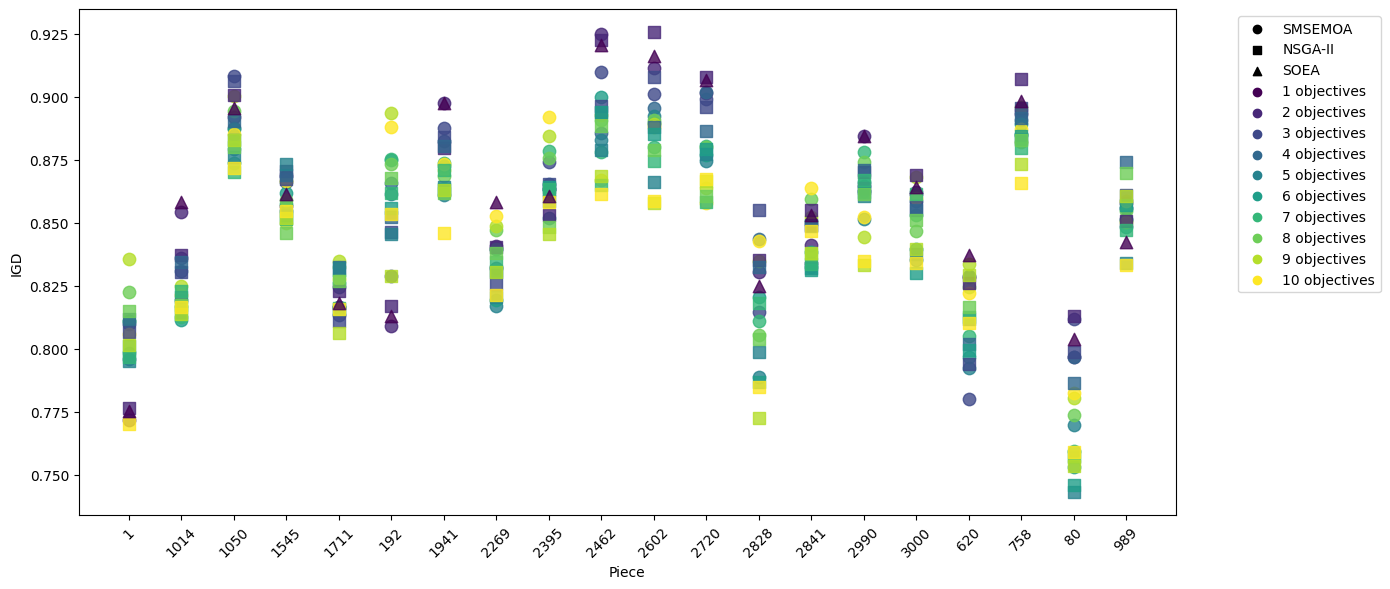

In [10]:
markers = {
    "SMSEMOA": "o",
    "NSGA-II": "s",
    "SOEA": "^"
}
unique_objectives = sorted(combined_GD["n_objectives"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_objectives)))
color_map = dict(zip(unique_objectives, colors))

def plot_piece_objective_scatter(df, metric_name):
    plt.figure(figsize=(14, 6))

    pieces = sorted(df["piece"].unique())
    x_map = {p: i for i, p in enumerate(pieces)}

    for _, row in df.iterrows():
        plt.scatter(
            x_map[row["piece"]],
            row[metric_name],
            marker=markers[row["algorithm"]],
            color=color_map[row["n_objectives"]],
            s=80,
            alpha=0.8
        )

    # X-axis formatting
    plt.xticks(range(len(pieces)), pieces, rotation=45)
    plt.xlabel("Piece")
    plt.ylabel(metric_name)
    #plt.title(f"{metric_name}: Algorithm (shape) & Objectives (color)")

    # Legend for algorithms (shapes)
    for algo, marker in markers.items():
        plt.scatter([], [], marker=marker, color='black', label=algo)

    # Legend for objectives (colors)
    for obj, color in color_map.items():
        plt.scatter([], [], marker='o', color=color, label=f"{obj} objectives")

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    outpath = os.path.join("experiments", "moea", "plots", f"{metric_name}_piece.pdf")
    plt.savefig(outpath, format="pdf", bbox_inches="tight")
    plt.show()
    
plot_piece_objective_scatter(combined_GD, "GD")
plot_piece_objective_scatter(combined_IGD, "IGD")

In [11]:
smsemoa_diversity = pd.read_csv(os.path.join(smsemoa_path, "diversity_SMSEMOA.csv"))
nsga_diversity = pd.read_csv(os.path.join(nsga_path, "diversity_NSGA2.csv"))
soea_diversity = pd.read_csv(os.path.join(ea_path,"diversity_EA.csv"))

# Ensure string type
nsga_diversity["piece"] = nsga_diversity["piece"].astype(str)
smsemoa_diversity["piece"] = smsemoa_diversity["piece"].astype(str)
soea_diversity["piece"] = soea_diversity["piece"].astype(str)

# Count number of objectives
smsemoa_diversity["n_objectives"] = smsemoa_diversity["objectives"].apply(lambda x: len(x.split("__")))
nsga_diversity["n_objectives"] = nsga_diversity["objectives"].apply(lambda x: len(x.split("__")))
soea_diversity["n_objectives"] = soea_diversity["objectives"].apply(lambda x: len(x.split("__")))

In [12]:
from scipy.stats import t
import numpy as np

def aggregate_diversity(df, confidence=0.95):
    grouped = df.groupby("n_objectives")["diversity"]

    result = grouped.agg(["mean", "std", "count"]).reset_index()
    dof = result["count"] - 1
    alpha = 1 - confidence
    t_crit = t.ppf(1 - alpha/2, dof)
    result["ci"] = t_crit * result["std"] / np.sqrt(result["count"])

    return result

In [13]:
smsemoa_div_obj = aggregate_diversity(smsemoa_diversity)
nsga_div_obj = aggregate_diversity(nsga_diversity)
soea_div_obj = aggregate_diversity(soea_diversity)

In [23]:
def plot_diversity_by_objectives(smsemoa, nsga, soea):
    x = np.array(sorted(smsemoa["n_objectives"].unique()))
    width = 0.2

    plt.figure(figsize=(12, 6))

    def plot_algo(offset, data, label):
        plt.errorbar(
            data["n_objectives"] + offset,
            data["mean"],
            yerr=data["ci"],
            fmt='o',
            label=label,
            capsize=4
        )

    plot_algo(-width, smsemoa, "SMSEMOA")
    plot_algo(0, nsga, "NSGA-II")
    plot_algo(0, soea, "SOEA")

    all_x = sorted(set(smsemoa["n_objectives"]) |
               set(nsga["n_objectives"]) |
               set(soea["n_objectives"]))

    plt.xticks(all_x)
    plt.xlabel("Number of Objectives")
    plt.ylabel("Diversity")
    #plt.title("Diversity vs Number of Objectives (95% CI)")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    outpath = os.path.join("experiments", "moea", "plots", "diversity_objectives.pdf")
    plt.savefig(outpath, format="pdf", bbox_inches="tight")
    plt.show()

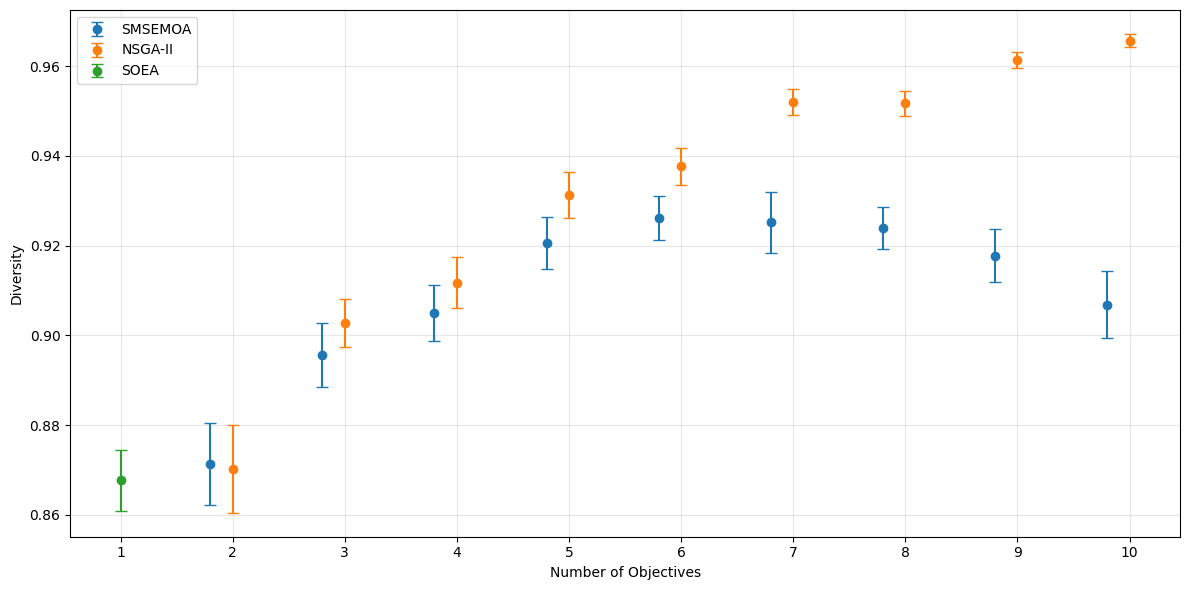

In [24]:
plot_diversity_by_objectives(
    smsemoa_div_obj,
    nsga_div_obj,
    soea_div_obj
)

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Register Times New Roman explicitly
font_path = r"C:\Windows\Fonts\times.ttf"
fm.fontManager.addfont(font_path)

times_new_roman = fm.FontProperties(fname=font_path).get_name()

# Paper-style settings
plt.rcParams.update({
    "font.family": times_new_roman,

    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,

    # Embed TrueType fonts in the PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def plot_diversity_by_objectives_emo(smsemoa, nsga, soea):
    x = np.array(sorted(smsemoa["n_objectives"].unique()))
    width = 0.2

    plt.figure(figsize=(12, 6))

    def plot_algo(offset, data, label):
        plt.errorbar(
            data["n_objectives"] + offset,
            data["mean"],
            yerr=data["ci"],
            fmt="o",
            label=label,
            capsize=5,
            capthick=1.5,
            markersize=7,
            linewidth=1.5
        )

    plot_algo(-width, smsemoa, "SMSEMOA")
    plot_algo(0, nsga, "NSGA-II")
    plot_algo(+width, soea, "SOEA")

    all_x = sorted(
        set(smsemoa["n_objectives"]) |
        set(nsga["n_objectives"]) |
        set(soea["n_objectives"])
    )

    plt.xticks(all_x)
    plt.xlabel("Number of Objectives")
    plt.ylabel("Diversity")

    plt.legend()

    plt.grid(alpha=0.3)
    plt.tight_layout()

    outpath = os.path.join(
        "experiments",
        "moea",
        "plots",
        "diversity_objectives.pdf"
    )

    plt.savefig(
        outpath,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()

meta NOT subset; don't know how to subset; dropped


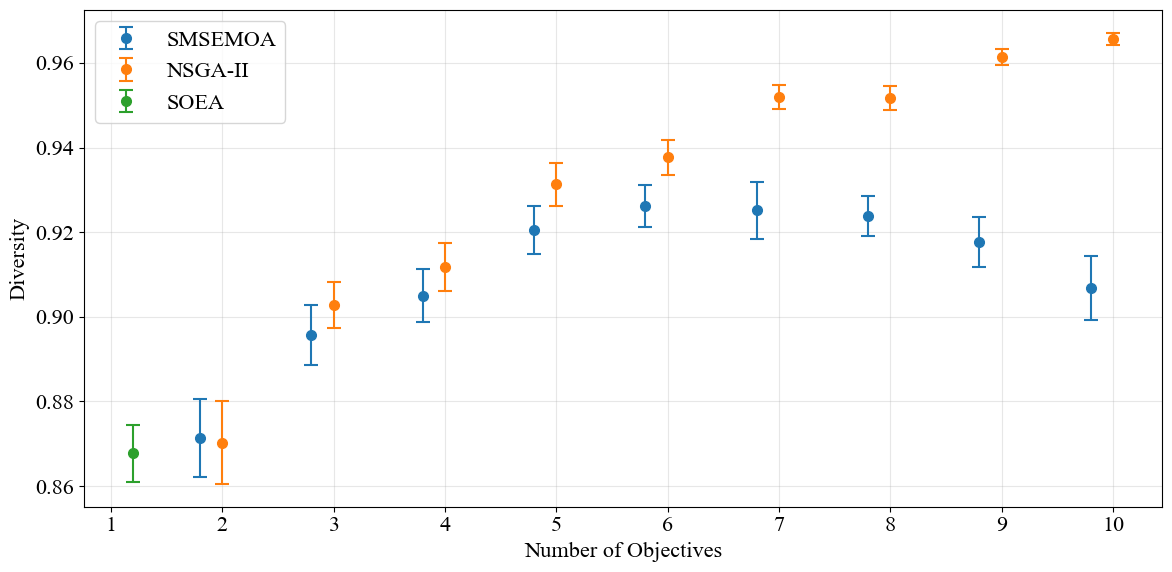

In [34]:
plot_diversity_by_objectives_emo(
    smsemoa_div_obj,
    nsga_div_obj,
    soea_div_obj
)

In [16]:
print(smsemoa_diversity["n_objectives"].value_counts().sort_index())
print(nsga_diversity["n_objectives"].value_counts().sort_index())
print(soea_diversity["n_objectives"].value_counts().sort_index())

n_objectives
2     200
3     200
4     200
5     200
6     200
7     200
8     200
9     200
10    200
Name: count, dtype: int64
n_objectives
2     200
3     200
4     200
5     200
6     200
7     200
8     200
9     200
10    200
Name: count, dtype: int64
n_objectives
1    400
Name: count, dtype: int64


In [17]:
print(summarize_by_objectives(nsga_df, "IGD"))

   n_objectives      mean       std  count        ci
0             2  0.859105  0.048196    200  0.006720
1             3  0.855864  0.044662    200  0.006228
2             4  0.854752  0.040470    200  0.005643
3             5  0.840517  0.041831    200  0.005833
4             6  0.841881  0.045669    200  0.006368
5             7  0.843184  0.038170    200  0.005322
6             8  0.845530  0.038487    200  0.005367
7             9  0.835899  0.039512    200  0.005510
8            10  0.833243  0.040276    200  0.005616


In [35]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def welch_one_sided_less(x, y):
    """
    H1: mean(x) < mean(y)
    """
    t_stat, p_two = ttest_ind(x, y, equal_var=False)

    if t_stat < 0:
        p_one = p_two / 2
    else:
        p_one = 1 - (p_two / 2)

    return t_stat, p_one


def test_moea_vs_soea(metric):
    results = []

    moea_dfs = {
        "NSGA-II": nsga_df,
        "SMSEMOA": smsemoa_df
    }

    soea_vals = soea_population_df[metric].dropna()
    for algo_name, df in moea_dfs.items():

        for n_obj in sorted(df["n_objectives"].unique()):

            moea_vals = df[df["n_objectives"] == n_obj][metric].dropna()

            if len(moea_vals) < 2 or len(soea_vals) < 2:
                continue

            t_stat, p_val = welch_one_sided_less(moea_vals, soea_vals)

            results.append({
                "metric": metric,
                "algorithm": algo_name,
                "n_objectives": n_obj,
                "mean_moea": moea_vals.mean(),
                "mean_soea": soea_vals.mean(),
                "diff": moea_vals.mean() - soea_vals.mean(),
                "t_stat": t_stat,
                "p_value": p_val,
                "n_moea": len(moea_vals),
                "n_soea": len(soea_vals)
            })

    df = pd.DataFrame(results)

    if df.empty:
        print(f"No valid comparisons for {metric}")
        return df

    df["p_fdr"] = multipletests(df["p_value"], method="fdr_bh")[1]
    df["significant_fdr"] = df["p_fdr"] < 0.05
    df["p_value_sci"] = df["p_value"].apply(lambda x: f"{x:.2e}")
    df["p_fdr_sci"] = df["p_fdr"].apply(lambda x: f"{x:.2e}")

    return df

In [36]:
gd_results = test_moea_vs_soea("GD")
igd_results = test_moea_vs_soea("IGD")

In [37]:
print(gd_results)

   metric algorithm  n_objectives  mean_moea  mean_soea      diff    t_stat  \
0      GD   NSGA-II             2   0.932830   0.936106 -0.003275 -0.786488   
1      GD   NSGA-II             3   0.931945   0.936106 -0.004161 -1.091299   
2      GD   NSGA-II             4   0.938974   0.936106  0.002869  0.845326   
3      GD   NSGA-II             5   0.932373   0.936106 -0.003733 -1.069006   
4      GD   NSGA-II             6   0.927004   0.936106 -0.009102 -2.298445   
5      GD   NSGA-II             7   0.934821   0.936106 -0.001285 -0.402639   
6      GD   NSGA-II             8   0.933001   0.936106 -0.003105 -0.922228   
7      GD   NSGA-II             9   0.927372   0.936106 -0.008734 -2.566949   
8      GD   NSGA-II            10   0.932810   0.936106 -0.003296 -1.009024   
9      GD   SMSEMOA             2   0.931901   0.936106 -0.004205 -0.946178   
10     GD   SMSEMOA             3   0.933564   0.936106 -0.002542 -0.686562   
11     GD   SMSEMOA             4   0.938743   0.936

In [38]:
print(igd_results)

   metric algorithm  n_objectives  mean_moea  mean_soea      diff    t_stat  \
0     IGD   NSGA-II             2   0.859105   0.859521 -0.000416 -0.099903   
1     IGD   NSGA-II             3   0.855864   0.859521 -0.003657 -0.922712   
2     IGD   NSGA-II             4   0.854752   0.859521 -0.004769 -1.278181   
3     IGD   NSGA-II             5   0.840517   0.859521 -0.019004 -4.993885   
4     IGD   NSGA-II             6   0.841881   0.859521 -0.017640 -4.388070   
5     IGD   NSGA-II             7   0.843184   0.859521 -0.016337 -4.528148   
6     IGD   NSGA-II             8   0.845530   0.859521 -0.013991 -3.859931   
7     IGD   NSGA-II             9   0.835899   0.859521 -0.023622 -6.419969   
8     IGD   NSGA-II            10   0.833243   0.859521 -0.026278 -7.062675   
9     IGD   SMSEMOA             2   0.856700   0.859521 -0.002821 -0.666988   
10    IGD   SMSEMOA             3   0.854565   0.859521 -0.004956 -1.233768   
11    IGD   SMSEMOA             4   0.856110   0.859